In [179]:
from sklearn.datasets import fetch_openml
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
import seaborn as sns
# module to evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, precision_recall_curve, classification_report

In [151]:
# fetch the mnist dataset from the sklearn dataset library

data_mnist = fetch_openml('mnist_784', as_frame=False)

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [152]:
# split the fetched data into data and target
X, y = data_mnist.data, data_mnist.target

In [153]:
# view few lines of the data and target
X[0:10]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [154]:
y[0:10]

array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4'], dtype=object)

In [155]:
#view the structure of the data

X.shape

(70000, 784)

In [156]:
y.shape

(70000,)

In [157]:
# view some digits in the dataset

# a function to view any digit

def view_any_digits(any_digit):
  view_digit = any_digit.reshape(28,28)
  plt.imshow(view_digit)
  plt.axis('off')

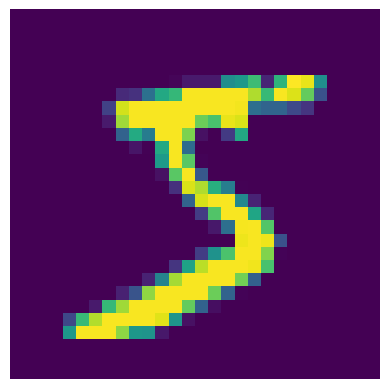

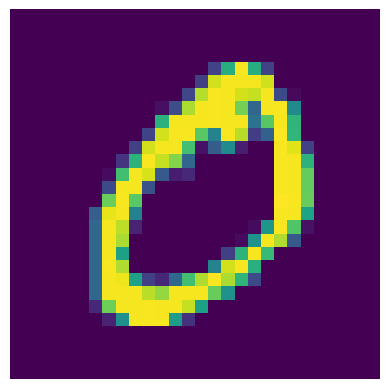

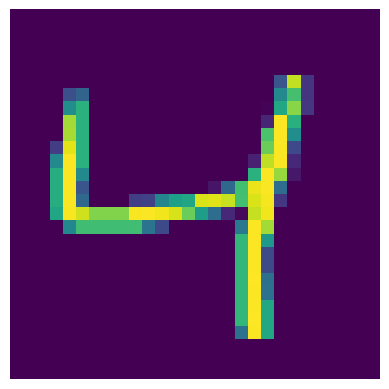

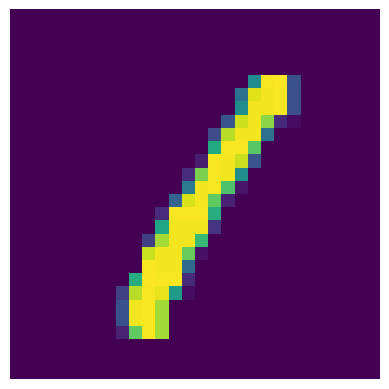

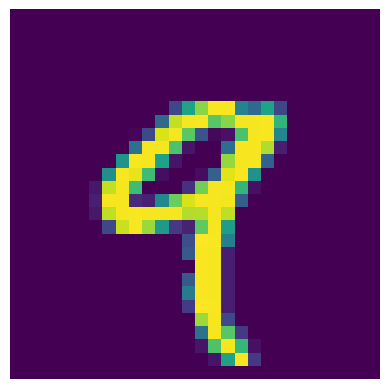

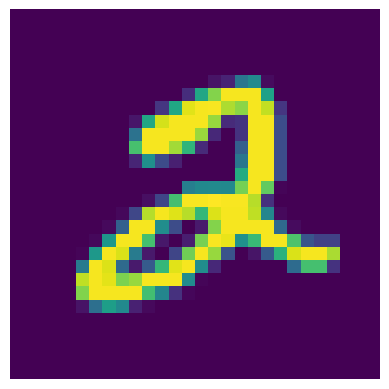

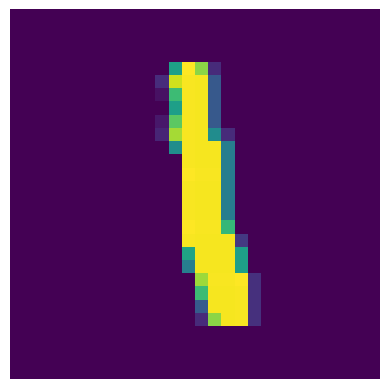

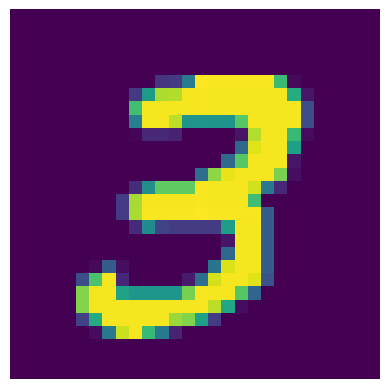

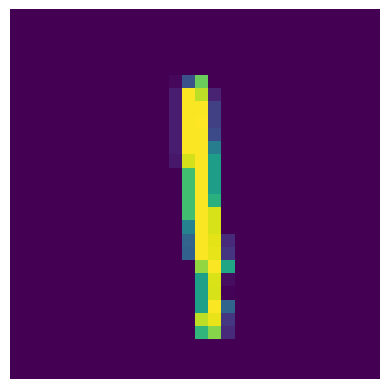

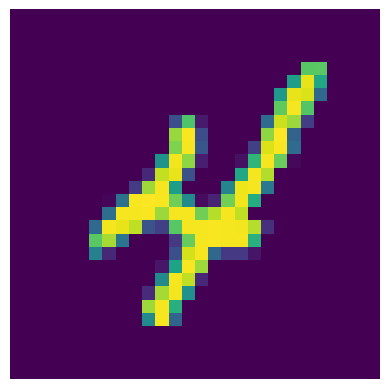

In [158]:
# view first 10  image digits
for i in range(0, 10):
  view_image = X[i]
  view_any_digits(view_image)
  plt.show()

In [159]:
# split the data into train, test dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.142, random_state=42)

In [160]:
X_train.shape

(60060, 784)

In [161]:
X_test.shape

(9940, 784)

In [162]:
# create a digit as the target label, for instance 2

y_train_2 = (y_train == '2')
y_test_2 = (y_test == '2')

Train an SGD Classifier

In [163]:
# model Training

sgd = SGDClassifier(random_state=42) # an object of the classifier



In [164]:
# train the classifier

model = sgd.fit(X_train, y_train_2)

In [165]:
# check the prediction on a known digit

test_for_digit = X[5]

model.predict([test_for_digit])

array([ True])

In [166]:
test_for_digit = X[3]
model.predict([test_for_digit])

array([False])

Evaluate the model

In [167]:
# create a prediction for the model

y_pred = model.predict(X_test)

In [170]:
# Accuracy score
accuracy = accuracy_score(y_test_2, y_pred)
print(accuracy)

0.9748490945674044


In [173]:
# precision score
precision = precision_score(y_test_2, y_pred)
print(precision)

0.9148191365227538


In [175]:
conf = confusion_matrix(y_test_2, y_pred)
print("Confusion Matrix\n")
print(conf)

Confusion Matrix

[[8906   73]
 [ 177  784]]


In [178]:
# produce a classification report

report = classification_report(y_test_2, y_pred)
print("--"*20)
print("--"*20)
print(report)

----------------------------------------
----------------------------------------
              precision    recall  f1-score   support

       False       0.98      0.99      0.99      8979
        True       0.91      0.82      0.86       961

    accuracy                           0.97      9940
   macro avg       0.95      0.90      0.92      9940
weighted avg       0.97      0.97      0.97      9940



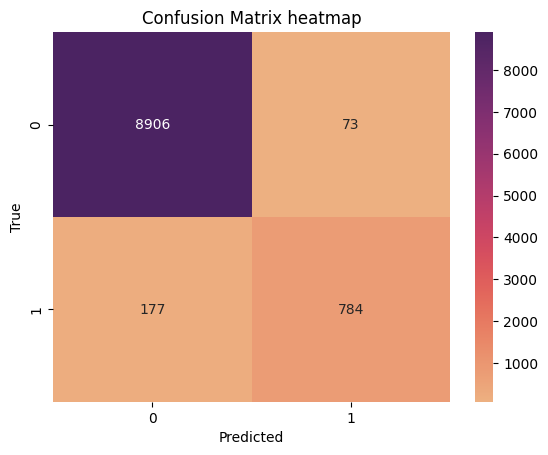

In [182]:
# plot the confusion matrix heatmap

sns.heatmap(conf, cmap='flare', annot=True, fmt='d')
plt.title("Confusion Matrix heatmap")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()